In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Install necessary libraries
!pip install datasets transformers --quiet

# Import libraries
from datasets import load_dataset
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from huggingface_hub import login

# Login to Hugging Face Hub using your token
login(token="your token")

# Load the dataset
dataset = load_dataset("sapienzanlp/nlp2025_hw1_cultural_dataset")

# Display the first few rows of the training set
df_train = pd.DataFrame(dataset["train"])
df_train.head()


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 491.4/491.4 kB 20.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 10.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 193.6/193.6 kB 14.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 143.5/143.5 kB 13.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.8/194.8 kB 15.0 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
torch 2.6.0+cu124 requires nvidia-cublas-cu12==12.4.5.8; platform_system == "Linux" and platform_machine == "x86_64", but you have nvidia-cublas-cu12 12.5.3.2 which is incompatible.
torch 2.6.0+cu124 requires nvidia-cuda-cupti-cu12==12.4.127; platform_system == "Linux" and platform_machine == "x86_64", but you have nvidia-cuda-cupti-cu12 12.5.82 which is incompatible.
torch 2.6.0+cu124 requires nvidia-cuda-nvrtc-cu12

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/2.31k [00:00<?, ?B/s]

train.csv:   0%|          | 0.00/946k [00:00<?, ?B/s]

valid.csv:   0%|          | 0.00/45.9k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/6251 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/300 [00:00<?, ? examples/s]

,item,name,description,type,category,subcategory,label
0,http://www.wikidata.org/entity/Q32786,916,2012 film by M. Mohanan,entity,films,film,cultural exclusive
1,http://www.wikidata.org/entity/Q371,!!!,American dance-punk band from California,entity,music,musical group,cultural representative
2,http://www.wikidata.org/entity/Q3729947,¡Soborno!,Mort & Phil comic,entity,comics and anime,comics,cultural representative
3,http://www.wikidata.org/entity/Q158611,+44,American band,entity,music,musical group,cultural representative
4,http://www.wikidata.org/entity/Q280375,1 Monk Street,"building in Monmouth, Wales",entity,architecture,building,cultural exclusive


In [ ]:
# Import necessary classes from the transformers library
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments
from transformers import DataCollatorWithPadding
import torch


In [ ]:
# Define a preprocessing function to combine relevant fields into a single text field
def preprocess(example):
    example["text"] = example["name"] + " - " + example["description"] + " - " + example["type"]  + " - " + example["category"]
    return example


In [ ]:
# Load the tokenizer for the DistilBERT model
tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")

# Define a tokenization function to tokenize the combined text field
def tokenize(example):
    return tokenizer(example["text"], truncation=True)


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

## TRAINING

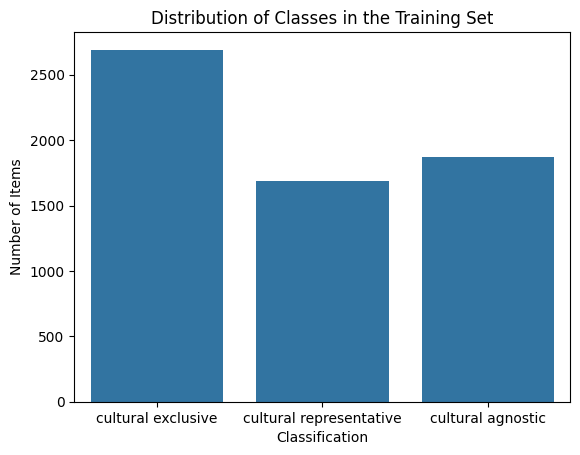

In [ ]:
# Plot the distribution of classes in the training set
sns.countplot(x="label", data=df_train)
plt.title("Distribution of Classes in the Training Set")
plt.xlabel("Classification")
plt.ylabel("Number of Items")
plt.show()


In [ ]:
# Apply the preprocessing function to the training and validation sets
dataset["train"] = dataset["train"].map(preprocess)
dataset["validation"] = dataset["validation"].map(preprocess)


Map:   0%|          | 0/6251 [00:00<?, ? examples/s]

Map:   0%|          | 0/300 [00:00<?, ? examples/s]

In [ ]:
# Apply the tokenization function to the training and validation sets
tokenized_train = dataset["train"].map(tokenize, batched=True)
tokenized_dev = dataset["validation"].map(tokenize, batched=True)


Map:   0%|          | 0/6251 [00:00<?, ? examples/s]

Map:   0%|          | 0/300 [00:00<?, ? examples/s]

In [ ]:
# Create dictionaries to map labels to IDs and vice versa
label2id = {"cultural agnostic": 0, "cultural representative": 1, "cultural exclusive": 2}
id2label = {v: k for k, v in label2id.items()}

# Define a function to encode labels into numerical IDs
def encode_labels(example):
    example["label"] = label2id[example["label"].lower()]
    return example

# Apply the label encoding function to the tokenized training and validation sets
tokenized_train = tokenized_train.map(encode_labels)
tokenized_dev = tokenized_dev.map(encode_labels)


Map:   0%|          | 0/6251 [00:00<?, ? examples/s]

Map:   0%|          | 0/300 [00:00<?, ? examples/s]

In [ ]:
# Load the DistilBERT model for sequence classification
distil_bert = AutoModelForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=3,  # Number of labels for classification
    id2label=id2label,  # Mapping from IDs to labels
    label2id=label2id   # Mapping from labels to IDs
)


Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [ ]:
# Freeze the parameters of the first three layers of the DistilBERT model
for param in distil_bert.distilbert.transformer.layer[:3]:
    for p in param.parameters():
        p.requires_grad = False  # Set requires_grad to False to prevent these parameters from being updated during training


In [ ]:
# Load the roBERTa model for sequence classification
bert = AutoModelForSequenceClassification.from_pretrained(
    "roberta-base",
    num_labels=3,  # Number of labels for classification
    id2label=id2label,  # Mapping from IDs to labels
    label2id=label2id   # Mapping from labels to IDs
)

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [ ]:
# Freeze the parameters of the first three layers of the roBERTa model
for param in bert.roberta.encoder.layer[:3]: # Access encoder.layer instead of transformer.layer
    for p in param.parameters():
        p.requires_grad = False  # Set requires_grad to False to prevent these parameters from being updated during training

In [ ]:
from transformers import TrainerCallback
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

import json
import os

# Define a function to compute evaluation metrics
def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    preds = predictions.argmax(axis=1)

    acc = accuracy_score(labels, preds)
    precision, recall, f1, _ = precision_recall_fscore_support(labels, preds, average='macro')

    return {
        "accuracy": acc,
        "precision": precision,
        "recall": recall,
        "f1": f1,
    }

# Custom callback to calculate and print metrics every few steps
class MetricsCallback(TrainerCallback):
    def __init__(self, logging_steps=10):
        self.logging_steps = logging_steps

    def on_step_end(self, args, state, control, **kwargs):
        if "outputs" in kwargs and state.global_step % self.logging_steps == 0:
            # Calculate metrics
            predictions, labels = kwargs['outputs']
            metrics = compute_metrics((predictions, labels))
            print(f"Step {state.global_step}: {metrics}")
        return control

# Custom callback to log metrics to a JSON file
class JSONLoggerCallback(TrainerCallback):
    def __init__(self, log_file_path="./logs/training_logs.jsonl"):
        self.log_file_path = log_file_path
        os.makedirs(os.path.dirname(log_file_path), exist_ok=True)

    def on_log(self, args, state, control, logs=None, **kwargs):
        if logs is not None:
            with open(self.log_file_path, "a") as f:
                logs["step"] = state.global_step
                json.dump(logs, f)
                f.write("\n")


In [ ]:
# Set the device to GPU if available, otherwise use CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Define training arguments
training_args = TrainingArguments(
    output_dir="./results",  # Directory to save the model checkpoints
    eval_strategy="steps",  # Evaluation strategy to use
    save_strategy="epoch",  # Save the model at the end of each epoch
    per_device_train_batch_size=64,  # Batch size for training
    per_device_eval_batch_size=64,  # Batch size for evaluation
    num_train_epochs=3,  # Number of training epochs
    weight_decay=0.01,  # Weight decay for regularization
    logging_steps=10,  # Log metrics every 10 steps
    logging_dir="./logs",  # Directory to save the logs
    report_to="tensorboard"  # Report metrics to TensorBoard
)

In [ ]:
# Move the model to the GPU if available
distil_bert.to(device)

# Initialize the Trainer
trainer_distilbert = Trainer(
    model=distil_bert,  # The model to be trained
    args=training_args,  # Training arguments
    train_dataset=tokenized_train,  # Training dataset
    eval_dataset=tokenized_dev,  # Evaluation dataset
    tokenizer=tokenizer,  # Tokenizer
    data_collator=DataCollatorWithPadding(tokenizer),  # Data collator for padding
    compute_metrics=compute_metrics,  # Function to compute metrics
    callbacks=[JSONLoggerCallback()]  # Custom callback for logging
)

# Start training
trainer_distilbert.train()


<ipython-input-16-937b3f64b279>:5: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer_distilbert = Trainer(


Step,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1,
10,0.986400,0.949963,0.596667,0.394587,0.614485,0.477123,10
20,0.794500,0.711233,0.636667,0.601200,0.622376,0.597276,20
30,0.665700,0.696963,0.646667,0.634343,0.645494,0.612176,30
40,0.574100,0.683416,0.686667,0.667292,0.678000,0.655976,40
50,0.557600,0.618809,0.706667,0.683645,0.693678,0.684520,50
60,0.568600,0.650024,0.710000,0.688772,0.701077,0.684091,60
70,0.498000,0.627352,0.736667,0.720539,0.729545,0.713266,70
80,0.584500,0.585110,0.750000,0.731620,0.736718,0.732916,80
90,0.485100,0.594977,0.756667,0.750355,0.754590,0.735364,90
100,0.476600,0.561925,0.743333,0.724906,0.718518,0.719103,100


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


TrainOutput(global_step=294, training_loss=0.483944160597665, metrics={'train_runtime': 70.1479, 'train_samples_per_second': 267.335, 'train_steps_per_second': 4.191, 'total_flos': 207287750622348.0, 'train_loss': 0.483944160597665, 'epoch': 3.0, 'step': 294})

In [ ]:
# Move the model to the GPU if available
bert.to(device)

# Initialize the Trainer
trainer_bert = Trainer(
    model=bert,  # The model to be trained
    args=training_args,  # Training arguments
    train_dataset=tokenized_train,  # Training dataset
    eval_dataset=tokenized_dev,  # Evaluation dataset
    tokenizer=tokenizer,  # Tokenizer
    data_collator=DataCollatorWithPadding(tokenizer),  # Data collator for padding
    compute_metrics=compute_metrics,  # Function to compute metrics
    callbacks=[JSONLoggerCallback()]  # Custom callback for logging
)

# Start training
trainer_bert.train()


<ipython-input-17-9a96667e7dd4>:5: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer_bert = Trainer(


Step,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1,
10,1.078600,1.104502,0.416667,0.329924,0.466787,0.341519,10
20,1.074200,1.014074,0.533333,0.355068,0.552669,0.427960,20
30,0.974100,0.972831,0.536667,0.356804,0.555518,0.430375,30
40,0.955300,0.995944,0.536667,0.356804,0.555518,0.430375,40
50,0.963400,0.959395,0.546667,0.363442,0.565602,0.438308,50
60,0.940900,0.940527,0.570000,0.566728,0.585461,0.521381,60
70,0.919200,0.968394,0.563333,0.602128,0.578431,0.498759,70
80,0.951400,0.935337,0.570000,0.590807,0.581177,0.535301,80
90,0.868800,0.913668,0.586667,0.600000,0.594950,0.556279,90
100,0.840100,0.897318,0.603333,0.603463,0.604911,0.579155,100


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/m

TrainOutput(global_step=294, training_loss=0.8138540829120039, metrics={'train_runtime': 162.8227, 'train_samples_per_second': 115.174, 'train_steps_per_second': 1.806, 'total_flos': 411718026044556.0, 'train_loss': 0.8138540829120039, 'epoch': 3.0, 'step': 294})

In [ ]:
# Choose the model (we choose distil_bert beacuse have the best accuracy)
trainer = trainer_distilbert

In [ ]:
# Save the final model at the end of training
trainer.save_model("/content/drive/MyDrive/The_Giadas_shared_folder/final_model1")

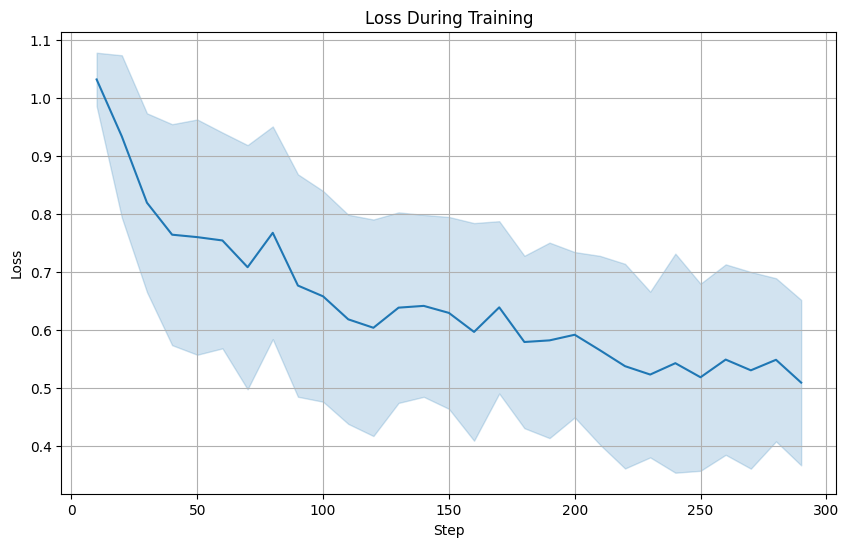

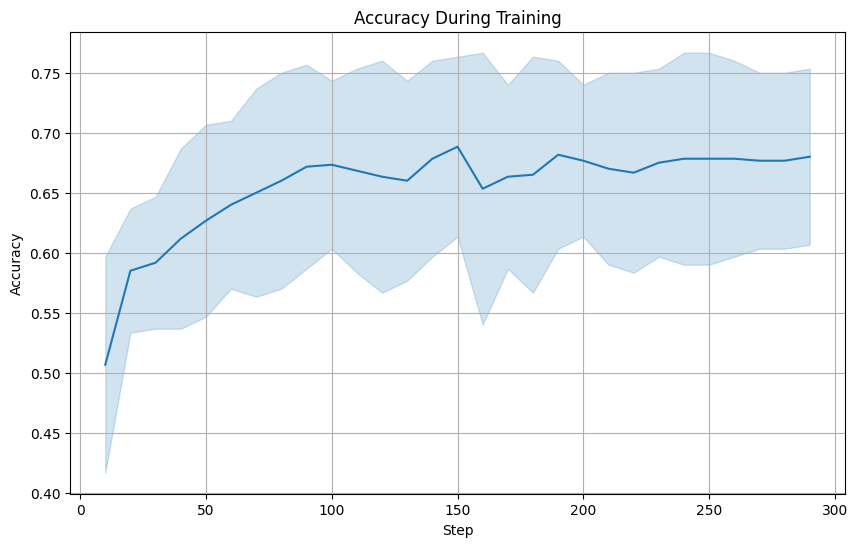

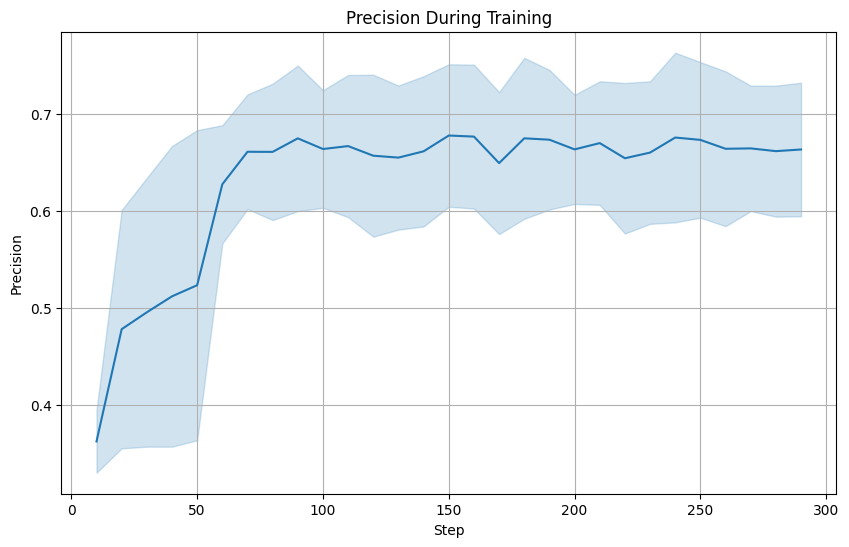

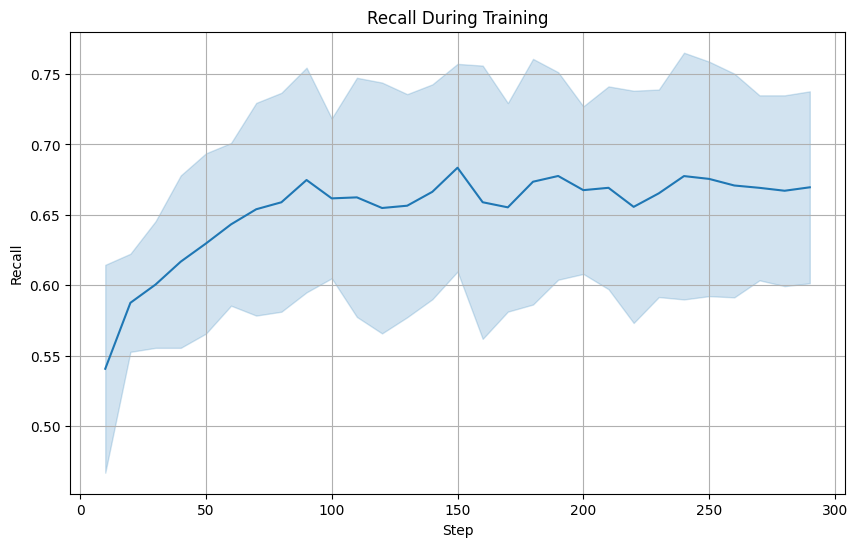

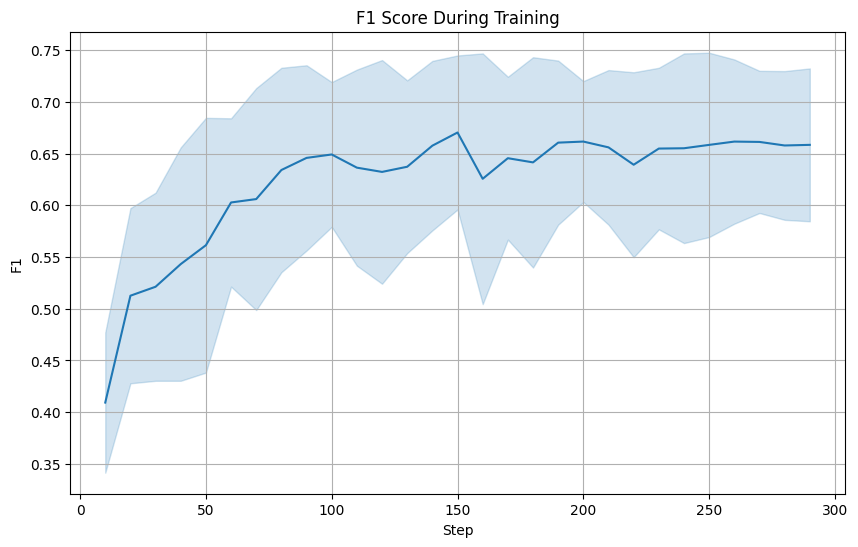

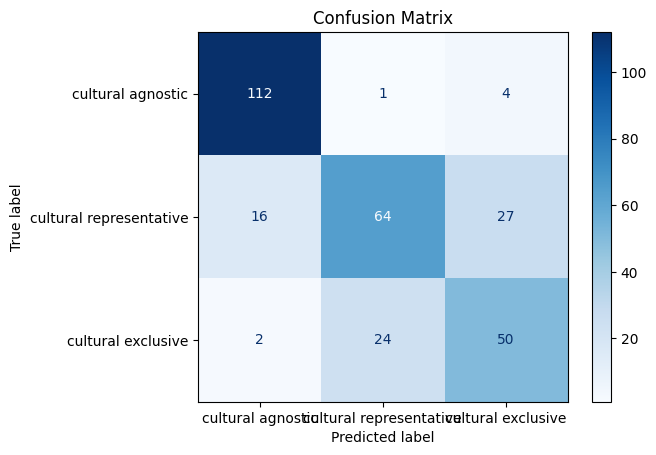

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay # Import confusion_matrix and ConfusionMatrixDisplay
import numpy as np
# Read logs from the file
log_path = "./logs/training_logs.jsonl"
log_data = []

with open(log_path, 'r') as f:
    for line in f:
        try:
            log_data.append(json.loads(line))
        except:
            pass

log_df = pd.DataFrame(log_data)

# Plot the loss during training
plt.figure(figsize=(10, 6))
sns.lineplot(data=log_df, x="step", y="loss")
plt.title("Loss During Training")
plt.xlabel("Step")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

# Plot the accuracy during training
plt.figure(figsize=(10, 6))
sns.lineplot(data=log_df, x="step", y="eval_accuracy")
plt.title("Accuracy During Training")
plt.xlabel("Step")
plt.ylabel("Accuracy")
plt.grid(True)
plt.show()

# Plot the precision during training
plt.figure(figsize=(10, 6))
sns.lineplot(data=log_df, x="step", y="eval_precision")
plt.title("Precision During Training")
plt.xlabel("Step")
plt.ylabel("Precision")
plt.grid(True)
plt.show()

# Plot the recall during training
plt.figure(figsize=(10, 6))
sns.lineplot(data=log_df, x="step", y="eval_recall")
plt.title("Recall During Training")
plt.xlabel("Step")
plt.ylabel("Recall")
plt.grid(True)
plt.show()

# Plot the F1 score during training
plt.figure(figsize=(10, 6))
sns.lineplot(data=log_df, x="step", y="eval_f1")
plt.title("F1 Score During Training")
plt.xlabel("Step")
plt.ylabel("F1")
plt.grid(True)
plt.show()

# Valutazione sul set di validazione
predictions = trainer.predict(tokenized_dev)
y_pred = np.argmax(predictions.predictions, axis=1)
y_true = predictions.label_ids
# Calcola la confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Opzionale: se hai nomi delle classi
labels = ["cultural agnostic", "cultural representative", "cultural exclusive"]

# Visualizza la confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(cmap='Blues')  # Colormap opzionale
plt.title("Confusion Matrix")
plt.show()

## TEST

In [ ]:
from transformers import AutoModelForSequenceClassification
from transformers import Trainer
import os
os.environ["WANDB_DISABLED"] = "true"
from transformers import AutoTokenizer, TrainingArguments # Import TrainingArguments

# Carica il modello salvato
model = AutoModelForSequenceClassification.from_pretrained("/content/drive/MyDrive/The_Giadas_shared_folder/final_model1")

# Carica il tokenizer salvato insieme al modello
tokenizer = AutoTokenizer.from_pretrained("/content/drive/MyDrive/The_Giadas_shared_folder/final_model1")


training_args = TrainingArguments(
    output_dir="./results",
    eval_strategy="steps",
    save_strategy="epoch",
    per_device_train_batch_size=64,
    per_device_eval_batch_size=64,
    num_train_epochs=3,
    weight_decay=0.01,
    logging_steps=10,
    logging_dir="./logs",
    report_to="flag"
)


trainer = Trainer(
    model=model,
    processing_class=tokenizer
)

Using the `WANDB_DISABLED` environment variable is deprecated and will be removed in v5. Use the --report_to flag to control the integrations used for logging result (for instance --report_to none).


In [ ]:
# Step 1: Prepara il test set
test_dataset = pd.read_csv('/content/drive/MyDrive/The_Giadas_shared_folder/test_unlabeled.csv')

# Convert the DataFrame to a list of dictionaries
test_dataset = test_dataset.to_dict('records')

# Apply the preprocessing function to each dictionary in the list
processed_data = [preprocess(example) for example in test_dataset]

# Convert the processed list of dictionaries back to a DataFrame
processed_df = pd.DataFrame(processed_data)

# Convert the pandas DataFrame to a Hugging Face Dataset
import datasets
test_dataset_hf = datasets.Dataset.from_pandas(processed_df)

# Se hai già queste funzioni definite prima (preprocess e tokenize), le riutilizzi:
# Use the Hugging Face Dataset here
tokenized_test = test_dataset_hf.map(tokenize, batched=True)


# Step 2: Genera predizioni
pred_output = trainer.predict(tokenized_test)
pred_classes = pred_output.predictions.argmax(axis=1)

# Mappa i numeri in etichette testuali
id2label = {
    0: "cultural agnostic",
    1: "cultural representative",
    2: "cultural exclusive"
}
pred_labels = [id2label[i] for i in pred_classes]

# Step 3: Salva in CSV
import pandas as pd

# Recupera le colonne originali dal test set
# Use the processed DataFrame here as well
df_test = pd.DataFrame(processed_df)
df_test["label"] = pred_labels

# Salva
df_test.to_csv("/content/drive/MyDrive/The_Giadas_shared_folder/The_Giadas_output_modello1.csv", index=False)


Map:   0%|          | 0/300 [00:00<?, ? examples/s]

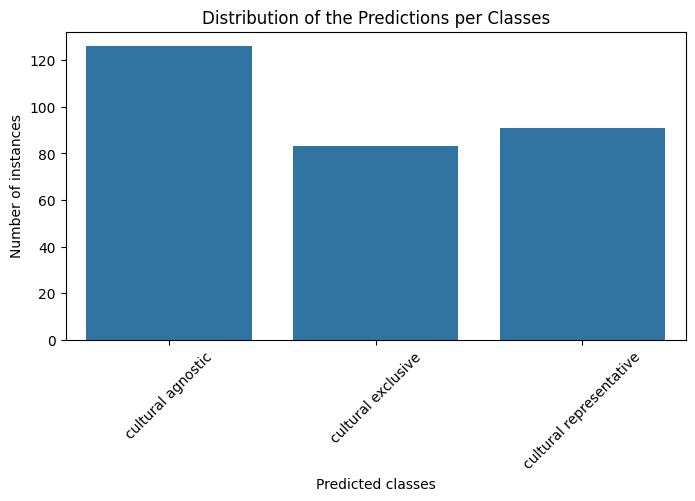

In [ ]:
import seaborn as sns

plt.figure(figsize=(8, 4))
sns.countplot(x=pred_labels, order=sorted(set(pred_labels)))
plt.title("Distribution of the Predictions per Classes")
plt.xlabel("Predicted classes")
plt.ylabel("Number of instances")
plt.xticks(rotation=45)
plt.show()
